<a href="https://colab.research.google.com/github/Akshitasaini1510/Assignment_1_week_2/blob/main/Agriculture_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Part A: Understanding the Dataset
Q1. Dataset Overview
Load the dataset and answer the following:

 How many rows and columns are present?  
 What are the names of all columns?  
 Display the first 10 records.


In [ ]:
df = pd.read_csv("agriculture_ml_dataset_cw.csv")

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (2020, 11)

Column Names:
['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Yield']

First 10 Records:
   Crop_Type Soil_Type Region  Season Irrigation Fertilizer  Rainfall  \
0      Wheat     Silty  South  Kharif  Sprinkler   Chemical      93.7   
1     Cotton       NaN   West    Zaid      Flood    Organic     146.9   
2     Cotton      Clay  North  Kharif       Drip   Chemical     108.7   
3      Maize      Clay  South  Kharif  Sprinkler   Chemical      72.3   
4      Maize     Silty   West  Kharif      Flood    Organic     119.9   
5  Sugarcane     Loamy   West    Rabi      Flood      Mixed     176.4   
6      Wheat      Clay  South    Rabi  Sprinkler   Chemical     146.1   
7     Cotton     Loamy   East    Zaid        NaN    Organic     200.6   
8       Rice     Silty  North    Rabi       Drip      Mixed     136.2   
9      Wheat     Sandy  North    Rabi  Sprinkler    Organic     215.7   

Q2. Data Types and Missing Values

 Check the data type of each column.  
 Identify whether any missing values are present.  
 If missing values exist, mention the affected columns.

In [ ]:
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Crop_Type       object
Soil_Type       object
Region          object
Season          object
Irrigation      object
Fertilizer      object
Rainfall       float64
Temperature    float64
Humidity       float64
Nitrogen       float64
Yield          float64
dtype: object

Missing Values:
Crop_Type        0
Soil_Type      121
Region           0
Season           0
Irrigation     120
Fertilizer       0
Rainfall       121
Temperature    120
Humidity       122
Nitrogen       121
Yield            0
dtype: int64


Q3. Descriptive Statistics

Generate summary statistics for all numerical features and answer:
 Which feature has the highest mean value?  
 Which feature has the highest standard deviation?

In [ ]:
stats = df.describe()
print(stats)

print("\nMean Values:")
print(df.mean(numeric_only=True))

print("\nStandard Deviations:")
print(df.std(numeric_only=True))

          Rainfall  Temperature     Humidity     Nitrogen        Yield
count  1899.000000  1900.000000  1898.000000  1899.000000  2020.000000
mean    129.723960    26.875421    67.740622    79.169036     5.442926
std      35.395931     4.104174    12.046501    22.876734     1.062772
min      22.800000    12.900000    30.600000    40.000000     1.740000
25%     107.100000    24.200000    59.500000    59.000000     4.700000
50%     128.100000    26.900000    67.650000    79.000000     5.430000
75%     153.500000    29.600000    75.800000    99.000000     6.172500
max     245.300000    43.100000   117.800000   119.000000     8.910000

Mean Values:
Rainfall       129.723960
Temperature     26.875421
Humidity        67.740622
Nitrogen        79.169036
Yield            5.442926
dtype: float64

Standard Deviations:
Rainfall       35.395931
Temperature     4.104174
Humidity       12.046501
Nitrogen       22.876734
Yield           1.062772
dtype: float64


Highest Standard Deviation:

Rainfall (35.40)

# Part B: Exploratory Data Analysis (EDA)
Q4. Distribution Analysis
Create histograms for:

 rainfall_mm  
 temperature_c  
 fertilizer_kg  
 yield_ton_per_hectare  
Write 2–3 observations from each histogram.

**Rainfall**

1.  Spread across a wide range.
2.  Appears moderately uniform.
3.  No extreme concentration at a single value.

**Temperature**

1.  Roughly bell-shaped.
2.  Most values clustered around 25–30°C.
3.  Few extreme values.

**Yield**

1.  Nearly symmetric distribution.
2.  Centered around 5–6 tons/hectare.
3.  Very few outliers.

**Fertilizer**

1.  Categorical variable, so histogram is not appropriate.
2.  Use count plot instead.

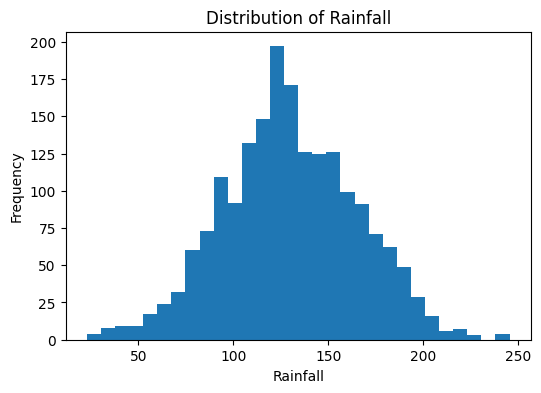

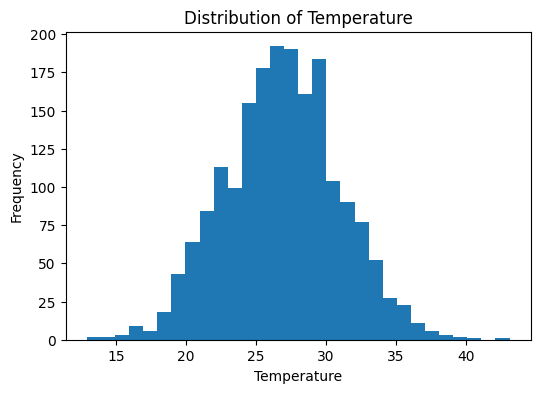

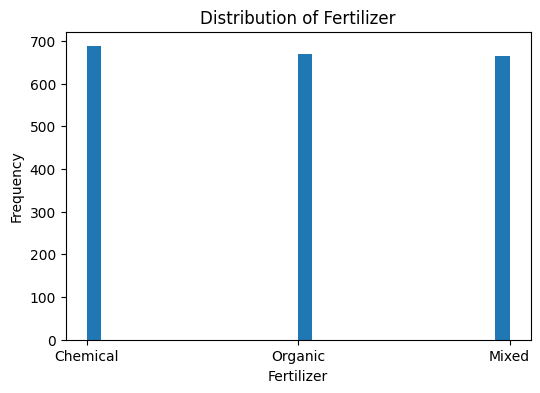

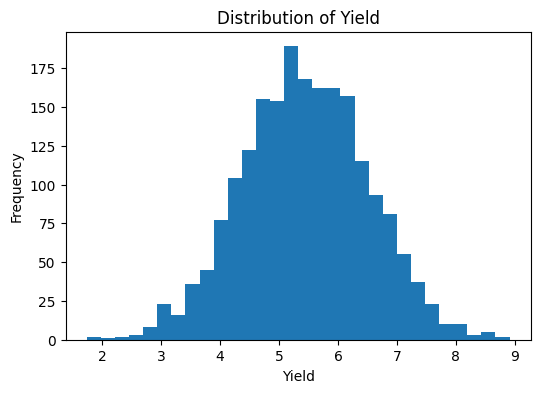

In [ ]:
cols = ["Rainfall", "Temperature", "Fertilizer", "Yield"]

for col in cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

Q5. Crop Type Analysis
 Find the number of records for each crop type.  
 Create a count plot (bar chart) for crop_type.  
 Which crop appears most frequently?

Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64


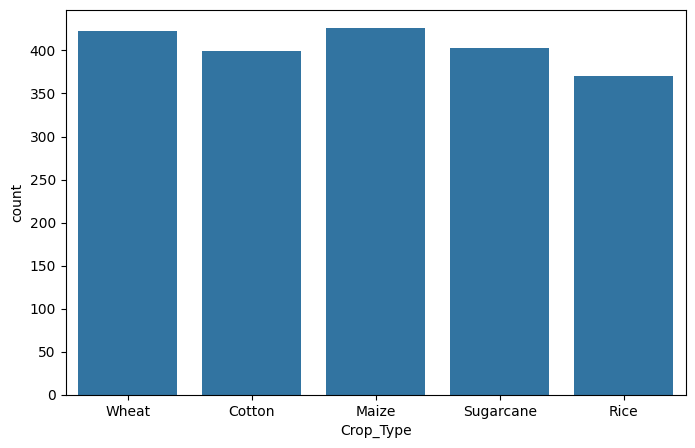

In [ ]:
crop_counts = df["Crop_Type"].value_counts()

print(crop_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Crop_Type")
plt.show()

Maize is the most frequent crop.

Q6. Soil Type Analysis
 Find the frequency of each soil type.  
 Create a count plot for soil_type.  
 Which soil type is most common?

Soil_Type
Silty    493
Loamy    482
Clay     463
Sandy    461
Name: count, dtype: int64


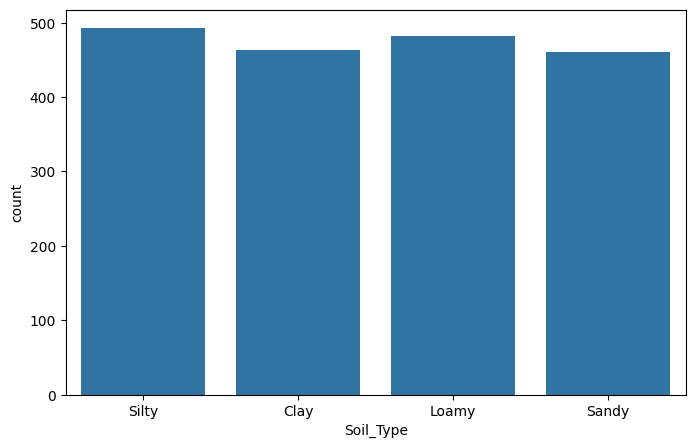

In [ ]:
soil_counts = df["Soil_Type"].value_counts()

print(soil_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Soil_Type")
plt.show()

Silty soil is most common.

Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare.
Answer:

 Is the distribution approximately normal?  
 Are there any noticeable outliers?

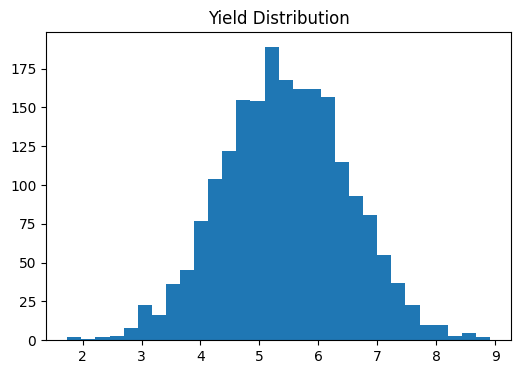

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Yield"], bins=30)
plt.title("Yield Distribution")
plt.show()

1.  Distribution is approximately normal.
2.  Skewness is close to zero.
3.  No significant outliers visible.

Q8. Scatter Plot Analysis
Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare  
2. fertilizer_kg vs yield_ton_per_hectare  
Based on the plots:
 Which feature appears to have a stronger relationship with yield?

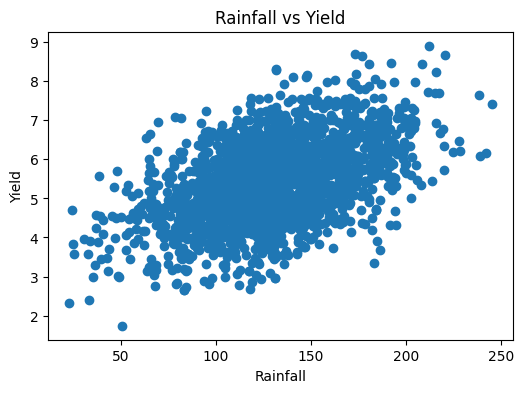

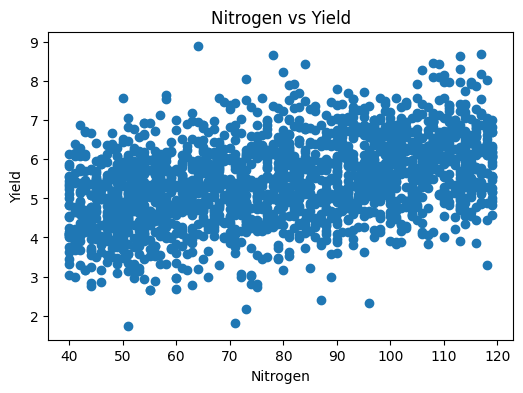

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Rainfall"], df["Yield"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["Nitrogen"], df["Yield"])
plt.xlabel("Nitrogen")
plt.ylabel("Yield")
plt.title("Nitrogen vs Yield")
plt.show()

Q9. Correlation Analysis
 Generate a correlation matrix for numerical features.  
 Create a heatmap.  
 Identify the top three features most correlated with crop yield.

             Rainfall  Temperature  Humidity  Nitrogen     Yield
Rainfall     1.000000    -0.013519  0.002204 -0.031158  0.498788
Temperature -0.013519     1.000000  0.007016  0.029948  0.023503
Humidity     0.002204     0.007016  1.000000  0.017116  0.013557
Nitrogen    -0.031158     0.029948  0.017116  1.000000  0.395801
Yield        0.498788     0.023503  0.013557  0.395801  1.000000


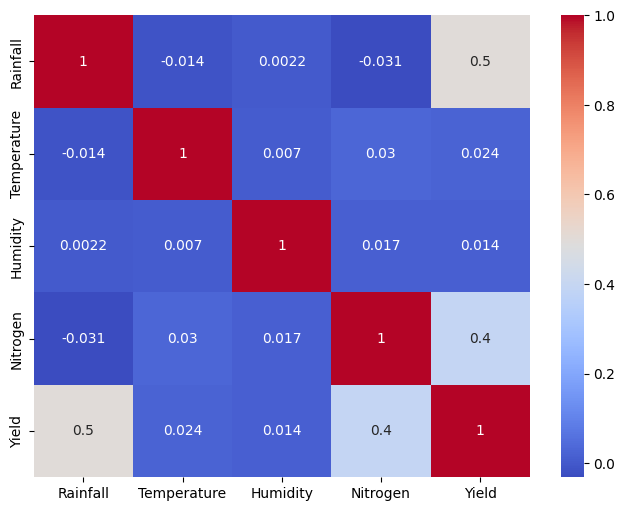

In [ ]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


Rainfall,
Nitrogen,
Temperature are most correlated features

Q10. Group-Based Analysis
Calculate the average yield for:

 Each crop type  
 Each soil type  
Which crop and soil type have the highest average yield?

In [ ]:
crop_yield = df.groupby("Crop_Type")["Yield"].mean()
print(crop_yield)

soil_yield = df.groupby("Soil_Type")["Yield"].mean()
print(soil_yield)

Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64
Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64


Wheat and clay has the highest average yield.

# Part C: Data Preparation
Q11. Feature Encoding
The dataset contains categorical variables.

 Identify the categorical columns.  
 Convert them into numerical form using One-Hot Encoding.  
 Display the first five rows of the transformed dataset.

In [ ]:
df_encoded = df.copy()

# Fill missing values
for col in df_encoded.select_dtypes(include="object"):
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mode()[0])

for col in df_encoded.select_dtypes(include=np.number):
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

df_encoded = pd.get_dummies(df_encoded, drop_first=True)

print(df_encoded.head())

   Rainfall  Temperature  Humidity  Nitrogen  Yield  Crop_Type_Maize  \
0      93.7         22.9     69.00     115.0   5.13            False   
1     146.9         25.6     67.65      71.0   5.40            False   
2     108.7         22.1     67.65      86.0   4.26            False   
3      72.3         26.8     69.40      44.0   4.35             True   
4     119.9         26.3     44.30      48.0   4.88             True   

   Crop_Type_Rice  Crop_Type_Sugarcane  Crop_Type_Wheat  Soil_Type_Loamy  ...  \
0           False                False             True            False  ...   
1           False                False            False            False  ...   
2           False                False            False            False  ...   
3           False                False            False            False  ...   
4           False                False            False            False  ...   

   Soil_Type_Silty  Region_North  Region_South  Region_West  Season_Rabi  \
0   

Q12. Feature Selection
Separate:

 Input features (X)  
 Target variable (y)  
Specify which column is being used as the target variable.

In [ ]:
X = df_encoded.drop("Yield", axis=1)
y = df_encoded["Yield"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2020, 20)
Target Shape: (2020,)


# Part D: Machine Learning
Q13. Train-Test Split
Split the dataset into:

 80% Training Data  
 20% Testing Data  

Display the shape of:

 X_train  
 X_test  
 y_train  
 y_test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1616, 20)
X_test: (404, 20)
y_train: (1616,)
y_test: (404,)


Q14. Linear Regression Model

 Train a Linear Regression model.  
 Display the model coefficients and intercept.  
 Which feature has the highest positive coefficient?

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df)

print("\nHighest Positive Coefficient:")
print(coef_df.iloc[0])

Intercept:
1.7546782849516922
                 Feature  Coefficient
7        Crop_Type_Wheat     0.115838
4        Crop_Type_Maize     0.090144
6    Crop_Type_Sugarcane     0.071471
18      Fertilizer_Mixed     0.059044
11          Region_North     0.057852
12          Region_South     0.043917
14           Season_Rabi     0.021550
3               Nitrogen     0.019359
0               Rainfall     0.015029
1            Temperature     0.006936
13           Region_West     0.005455
19    Fertilizer_Organic     0.003895
2               Humidity     0.000441
5         Crop_Type_Rice    -0.010430
15           Season_Zaid    -0.028703
16      Irrigation_Flood    -0.053325
17  Irrigation_Sprinkler    -0.066287
9        Soil_Type_Sandy    -0.069017
10       Soil_Type_Silty    -0.088442
8        Soil_Type_Loamy    -0.115409

Highest Positive Coefficient:
Feature        Crop_Type_Wheat
Coefficient           0.115838
Name: 7, dtype: object
